<a href="https://colab.research.google.com/github/nikolas-joyce/Event_Time/blob/main/Geothermal_Coin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Geothermal Token Price Simulation with Jump Diffusion

### Notebook Overview
This notebook simulates the potential price trajectories of a geothermal energy token over a 25-year period using a Jump Diffusion model. The primary goal is to understand the dynamic behavior of the token price, accounting for both continuous market volatility and discrete 'jump' events associated with project milestones like drilling.

The simulation also integrates a cumulative energy production profile, allowing for a comprehensive view of the project's financial and operational aspects. The output includes visualized price paths, percentile bands, and key summary statistics to assess the project's potential upside and risk.

### Key Concepts:

*   **Jump Diffusion Model**: A stochastic process that combines continuous random movements (like Geometric Brownian Motion) with sudden, discontinuous jumps. This is particularly useful for modeling asset prices that can experience abrupt changes due to specific events.
*   **Drilling Events**: Represent significant project milestones (e.g., successful well drilling) that can introduce sudden, positive 'jumps' in the token price, reflecting new value realization or market sentiment.
*   **Multiple Paths (Monte Carlo Simulation)**: By simulating `100` different price paths, we can explore a range of possible future scenarios rather than relying on a single deterministic forecast, providing a robust risk assessment.

### Important Parameters & Definitions:

*   **`total_tokens`**: The total supply of tokens in the system.
*   **`initial_token_price`**: The starting price of the token in USD.
*   **`energy_price_per_kwh`**: The base price of energy per kilowatt-hour, influencing token valuation.
*   **`discount_rate` (`mu`)**: The annual discount rate used in financial calculations, also serving as the drift rate for the continuous price component.
*   **`uptime_factor`**: A multiplier accounting for operational efficiency and availability of production facilities.
*   **`initial_investor_tokens`**: The number of tokens initially held by investors.
*   **`production_lifetime_kwh`**: The total expected energy production over the project's lifetime.
*   **`years`**: The total duration of the simulation (e.g., 25 years).
*   **`steps_per_year`**: The number of simulation steps within a year (e.g., 252 for trading days), determining the granularity of the simulation.
*   **`NUM_PATHS`**: The number of independent simulation trajectories (scenarios) to run (e.g., 100).
*   **`volatility_annual`**: The annual volatility (standard deviation) of the token price, representing the degree of continuous price fluctuations.

Market-Specific Benchmarks
* • ERCOT (Texas):      50-70% average, 150%+ spikes
* • PJM (US East):      40-60% base, 100%+ during peaks
* • EEX (Germany):      45-65% (Samuelson effect: decreases with maturity)
* • NEM (Australia):    60-90% (renewables + coal risk)
* • Ontario (IESO):     55-75% (nuclear + hydro dependent)

Renewable Baseload Benchmarks
* • Geothermal-linked (ERCOT/PJM):   30-45% (baseload stability)
* • Nuclear-heavy (France):           25-40% (dispatchable floor)
* • Firm hydro (Canada/Nordics):      35-50% (water variability)
* • NEM Australia baseload futures:   45-65% (renewable transition risk)
* • European baseload (EEX):          40-55% (gas correlation remains)

* • Conservative: 0.30 (nuclear-like stability)
* • Base case:    0.35-0.40 (ERCOT geothermal)
* • Stress case:  0.45-0.50 (policy/gas shocks)





*   **`JUMP_INTENSITY`**: The average number of jumps per year during drilling periods.
*   **`JUMP_MEAN`**: The average size of a price jump (as a percentage increase).
*   **`JUMP_VOL`**: The volatility of the jump size.
*   **`DRILLING_PERIODS`**: Specific time intervals (in simulation steps) when drilling events are active and price jumps can occur.

Simulating 100 Jump Diffusion paths with 5 drilling events


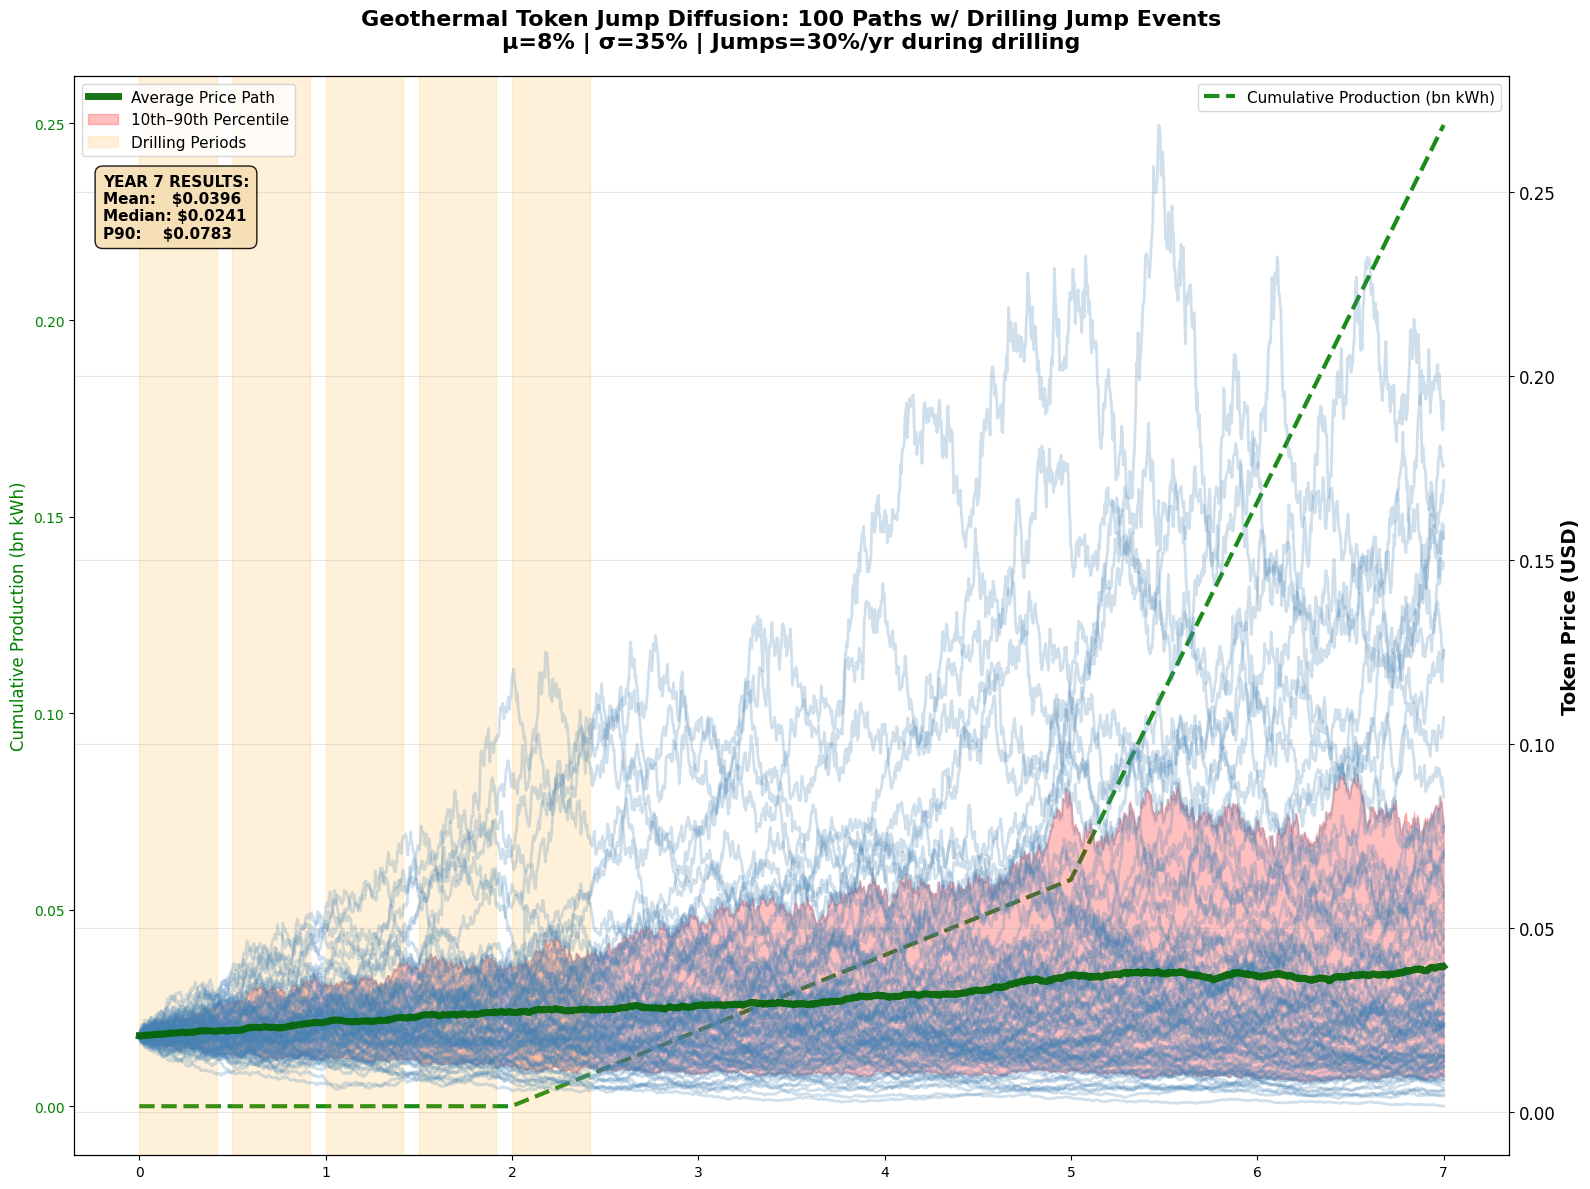


JUMP DIFFUSION SIMULATION RESULTS (5 Drilling Events)
                   Metric    Value
            Initial Price $0.02077
         Mean Final Price $0.03957
       Median Final Price $0.02408
          P10 Final Price $0.00954
          P90 Final Price $0.07832
Total Production (bn kWh)      0.2
        Upside Prob (>2x)    28.0%


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# PARAMETERS FROM CONTRACT SPECS
# =====================================================
total_tokens = 23_883_264_000
initial_token_price = 0.02077
energy_price_per_kwh = 0.06
discount_rate = 0.08            ## play with this
uptime_factor = 0.96
initial_investor_tokens = 1_925_847_112
production_lifetime_kwh = 23_883_264_000

# Simulation parameters
years = 7  ## sorten the time to view terminal values easier.
steps_per_year = 252
total_steps = years * steps_per_year
dt = 1 / steps_per_year
NUM_PATHS = 100

# Jump Diffusion Parameters (Drilling Events)
volatility_annual = 0.35       #### alter the Vol
JUMP_INTENSITY = 0.3
JUMP_MEAN = 0.15
JUMP_VOL = 0.10
mu = discount_rate

# Drilling schedule: 5 plants x 5 months drilling each, staggered
DRILLING_PERIODS = [
    (0, 105),      # Plant 1: months 0-5
    (126, 231),    # Plant 2: months 6-11
    (252, 357),    # Plant 3: months 12-17
    (378, 483),    # Plant 4: months 18-23
    (504, 609)     # Plant 5: months 24-29
]

print(f"Simulating {NUM_PATHS} Jump Diffusion paths with {len(DRILLING_PERIODS)} drilling events")

# =====================================================
# PRODUCTION RAMP-UP PROFILE
# =====================================================
def production_profile(time_steps):
    production = np.zeros(time_steps)
    production[504:] += 20e6 * uptime_factor / steps_per_year
    production[1260:] += 80e6 * uptime_factor / steps_per_year
    return production.cumsum()

# =====================================================
# JUMP DIFFUSION MODEL
# =====================================================
def simulate_jump_diffusion(initial_price, steps, mu, sigma, dt, n_paths, drilling_periods):
    prices = np.full((n_paths, steps), initial_price)

    for t in range(1, steps):
        drift = (mu - 0.5 * sigma**2) * dt
        gbm_shock = sigma * np.sqrt(dt) * np.random.normal(0, 1, n_paths)
        prices[:, t] = prices[:, t-1] * np.exp(drift + gbm_shock)

        if any(start <= t <= end for start, end in drilling_periods):
            jump_prob = JUMP_INTENSITY * dt
            jumps = np.random.random(n_paths) < jump_prob
            if np.any(jumps):
                jump_sizes = np.exp(np.random.normal(JUMP_MEAN, JUMP_VOL, np.sum(jumps)))
                prices[jumps, t] *= jump_sizes

    return prices

# =====================================================
# RUN SIMULATION
# =====================================================
production = production_profile(total_steps)
token_prices = simulate_jump_diffusion(
    initial_token_price, total_steps, mu, volatility_annual, dt, NUM_PATHS, DRILLING_PERIODS
)
time_axis = np.linspace(0, years, total_steps)

# =====================================================
# VISUALIZATION WITH NON-OVERLAPPING LEGENDS
# =====================================================
plt.figure(figsize=(16, 12))

ax1 = plt.gca()          # Left axis: production
ax2 = ax1.twinx()        # Right axis: token price

# 100 simulated paths
for i in range(NUM_PATHS):
    ax2.plot(time_axis, token_prices[i], alpha=0.25, lw=2.0, color='steelblue')

# Dark green average price path
mean_price = np.mean(token_prices, axis=0)
ax2.plot(time_axis, mean_price, color='darkgreen', lw=5, label='Average Price Path', alpha=0.9)

# 10–90 percentile band
p10 = np.percentile(token_prices, 10, axis=0)
p90 = np.percentile(token_prices, 90, axis=0)
ax2.fill_between(time_axis, p10, p90, alpha=0.25, color='red', label='10th–90th Percentile')

# Production (left axis)
prod_scaled = production / 1e9
ax1.plot(time_axis, prod_scaled, 'g--', lw=3, alpha=0.9, label='Cumulative Production (bn kWh)')

# Token price axis styling
ax2.set_ylabel('Token Price (USD)', color='black', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black', labelsize=12)
ax1.set_ylabel('Cumulative Production (bn kWh)', color='g', fontsize=12)
ax1.tick_params(axis='y', labelcolor='g')

# Drilling periods shaded
for start_step, end_step in DRILLING_PERIODS:
    start_year = start_step / steps_per_year
    end_year = end_step / steps_per_year
    ax2.axvspan(start_year, end_year, alpha=0.15, color='orange',
                label='Drilling Periods' if start_step == 0 else "")

plt.title(
    f'Geothermal Token Jump Diffusion: {NUM_PATHS} Paths w/ Drilling Jump Events\n'
    f'μ={mu:.0%} | σ={volatility_annual:.0%} | Jumps={JUMP_INTENSITY:.0%}/yr during drilling',
    fontsize=16, fontweight='bold', pad=20
)

ax2.set_xlabel('Years', fontsize=14)

# FIXED LEGENDS - NO OVERLAP
# Token price legend: upper left
ax2.legend(loc='upper left', fontsize=11)

# Production legend: upper right
ax1.legend(loc='upper right', fontsize=11)

ax2.grid(True, alpha=0.3)

# Stats box (moved slightly to avoid legend)
final_prices = token_prices[:, -1]
ax2.text(
    0.02, 0.85,  # Moved down from 0.98
    f'YEAR {years} RESULTS:\n'
    f'Mean:   ${np.mean(final_prices):.4f}\n'
    f'Median: ${np.median(final_prices):.4f}\n'
    f'P90:    ${np.percentile(final_prices, 90):.4f}',
    transform=ax2.transAxes,
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.9)
)

plt.tight_layout()
plt.show()

# =====================================================
# SUMMARY STATISTICS
# =====================================================
summary_stats = pd.DataFrame({
    'Metric': ['Initial Price', 'Mean Final Price', 'Median Final Price',
               'P10 Final Price', 'P90 Final Price', 'Total Production (bn kWh)',
               'Upside Prob (>2x)'],
    'Value': [
        f'${initial_token_price:.5f}',
        f'${np.mean(final_prices):.5f}',
        f'${np.median(final_prices):.5f}',
        f'${np.percentile(final_prices, 10):.5f}',
        f'${np.percentile(final_prices, 90):.5f}',
        f'{production[-1]/1e9:.1f}',
        f'{np.mean(final_prices > 2 * initial_token_price) * 100:.1f}%'
    ]
})

print("\n" + "="*70)
print("JUMP DIFFUSION SIMULATION RESULTS (5 Drilling Events)")
print("="*70)
print(summary_stats.to_string(index=False))


### Outputs:

*   **Interactive Plot**: Visualizes all simulated token price paths, the average price path, 10th-90th percentile bands, cumulative energy production, and highlights the drilling periods.
*   **Summary Statistics**: A table providing key metrics at the end of the simulation, such as mean/median final token prices, price percentiles, total production, and the probability of significant price appreciation (e.g., >2x initial price).

### Interpretation of Summary Statistics:

The summary statistics table provides a concise overview of the simulation results, highlighting key financial metrics and performance indicators for the geothermal token project:

*   **Initial Price**: This is the starting price of the token at the beginning of the simulation. It serves as a baseline for evaluating price appreciation.

*   **Mean Final Price**: The average token price across all simulated paths at the end of the 25-year period. This gives an overall expected price.

*   **Median Final Price**: The middle token price across all simulated paths at the end of the 25-year period. The median is often a more robust measure than the mean when dealing with skewed distributions, as it is less affected by extreme outliers.

*   **P10 Final Price (10th Percentile)**: This indicates that 10% of the simulated paths resulted in a final token price at or below this value. It represents a downside risk scenario.

*   **P90 Final Price (90th Percentile)**: This indicates that 90% of the simulated paths resulted in a final token price at or below this value. Conversely, only 10% of paths had a higher price. This represents a strong upside potential scenario.

*   **Total Production (bn kWh)**: The cumulative energy production over the entire simulation period, expressed in billions of kilowatt-hours. This quantifies the operational output of the project.

*   **Upside Prob (>2x)**: The probability (as a percentage) that the final token price will be more than double the initial token price. This is a key metric for assessing the investment potential and risk/reward profile of the token.